# ML Project - Decision Tree Airline Customer Satisfaction

## Import Libraries

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import seaborn as sns

In [4]:
import matplotlib.pyplot as plt

In [5]:
import warnings
warnings.filterwarnings('ignore')

## Import Data

In [6]:
pwd 

'C:\\Users\\OM\\Projects'

In [7]:
cd C:\Users\OM\OneDrive\Desktop\Projects

C:\Users\OM\OneDrive\Desktop\Projects


In [8]:
data = pd.read_csv("ML Project - Decision Tree Airline Customer Satisfaction.txt")

In [9]:
pd.set_option("display.max_columns",None)
pd.set_option('display.max_rows',None)

In [10]:
data.head(2)

,Unnamed: 0.1,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied


## Data information

In [11]:
data.shape

(10000, 26)

In [12]:
data.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age',
       'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [28]:
data["Flight_Distance"].unique()

array([ 460,  235, 1142, ..., 3033, 1319, 1443])

In [13]:
data.describe()

,Unnamed: 0.1,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9974.000000
mean,4999.50000,4999.50000,64950.978500,39.303700,1198.823800,2.731500,3.038900,2.753600,2.96890,3.208800,3.240300,3.411300,3.335500,3.366000,3.346500,3.619900,3.285600,3.627400,3.268200,14.785400,15.242130
std,2886.89568,2886.89568,37420.905082,15.116478,1001.774138,1.328226,1.528077,1.403241,1.28425,1.339769,1.350755,1.326012,1.340567,1.288336,1.311415,1.190028,1.269013,1.181401,1.321077,38.217509,38.810195
min,0.00000,0.00000,8.000000,7.000000,31.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2499.75000,2499.75000,32330.500000,27.000000,413.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,0.000000,0.000000
50%,4999.50000,4999.50000,64941.000000,40.000000,852.500000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,7499.25000,7499.25000,97579.750000,51.000000,1747.000000,4.000000,4.000000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,13.000000,13.000000
max,9999.00000,9999.00000,129863.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1305.000000,1280.000000


### Unique Values of Flight_Distance

In [69]:
data["Flight_Distance"].unique()

array([ 460,  235, 1142, ..., 3033, 1319, 1443])

## Necessary changes

### Drop Unnecessary Columns

In [14]:
data.drop(["Unnamed: 0.1","Unnamed: 0"], axis=1, inplace=True)

In [15]:
data.head(2)

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied


### Replace Columns Name

In [16]:
data.columns = data.columns.str.replace(" ","_")
data.columns

Index(['id', 'Gender', 'Customer_Type', 'Age', 'Type_of_Travel', 'Class',
       'Flight_Distance', 'Inflight_wifi_service',
       'Departure/Arrival_time_convenient', 'Ease_of_Online_booking',
       'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort',
       'Inflight_entertainment', 'On-board_service', 'Leg_room_service',
       'Baggage_handling', 'Checkin_service', 'Inflight_service',
       'Cleanliness', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes',
       'satisfaction'],
      dtype='object')

### Labeling Satisfaction Column

In [17]:
data["satisfaction"] = data["satisfaction"].map({"satisfied":1,"neutral or dissatisfied":0})

In [18]:
data.head()

,id,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure/Arrival_time_convenient,Ease_of_Online_booking,Gate_location,Food_and_drink,Online_boarding,Seat_comfort,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,0
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,0
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,1
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,0
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,1


### Drop Id Column

In [36]:
data.drop("id",axis=1, inplace=True)

## Satisfied VS Unsatisfied

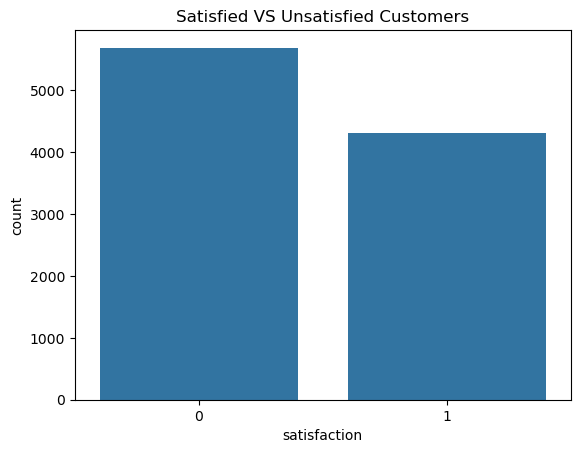

In [19]:
sns.countplot(x = "satisfaction",data=data)
plt.title("Satisfied VS Unsatisfied Customers");

## Mean Value of Satisfaction according Gender, Age and Food_and_drink

In [20]:
data.groupby("Gender")["satisfaction"].mean()

Gender
Female    0.424432
Male      0.438062
Name: satisfaction, dtype: float64

In [21]:
data.groupby("Age")["satisfaction"].mean()

Age
7     0.071429
8     0.081967
9     0.194030
10    0.137255
11    0.115942
12    0.214286
13    0.129032
14    0.076923
15    0.179104
16    0.154639
17    0.277228
18    0.266055
19    0.222222
20    0.296000
21    0.372414
22    0.399160
23    0.402778
24    0.381910
25    0.330882
26    0.329004
27    0.321739
28    0.401130
29    0.417526
30    0.410000
31    0.418750
32    0.402778
33    0.390110
34    0.356757
35    0.368984
36    0.415929
37    0.393519
38    0.407895
39    0.531746
40    0.551471
41    0.632743
42    0.563559
43    0.552632
44    0.596567
45    0.608466
46    0.643192
47    0.532407
48    0.575610
49    0.563877
50    0.545455
51    0.576355
52    0.583333
53    0.587065
54    0.568862
55    0.497076
56    0.508475
57    0.554913
58    0.564706
59    0.588235
60    0.555556
61    0.168539
62    0.230769
63    0.197183
64    0.218750
65    0.215385
66    0.050000
67    0.161290
68    0.187500
69    0.235294
70    0.222222
71    0.125000
72    0.250000
73    

In [22]:
data.groupby("Food_and_drink")["satisfaction"].mean()

Food_and_drink
0    0.625000
1    0.198142
2    0.362305
3    0.404990
4    0.515050
5    0.566176
Name: satisfaction, dtype: float64

## Boxplot

### Boxplot of Flight_Distance

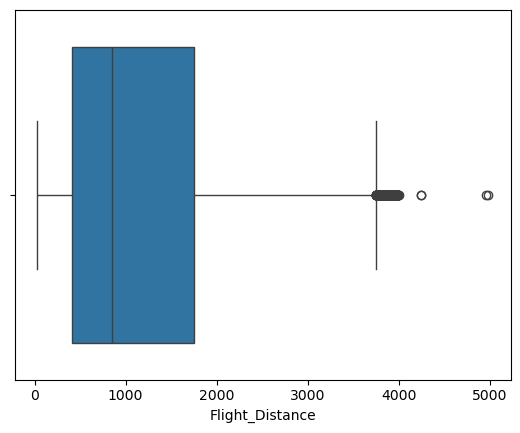

In [23]:
sns.boxplot(x = data["Flight_Distance"]);

### Boxplot of Checkin_service

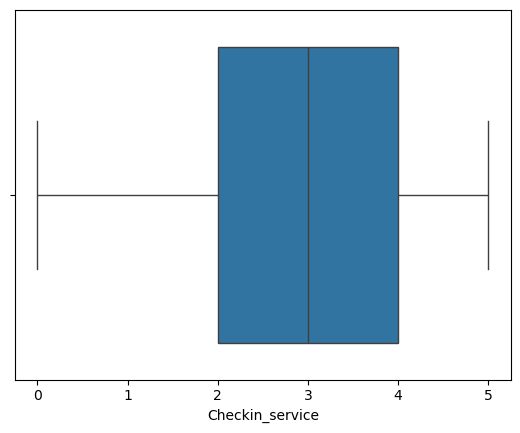

In [24]:
sns.boxplot(x = data["Checkin_service"]);

## Find and Drop Null Values

In [25]:
data.isnull().sum()

id                                    0
Gender                                0
Customer_Type                         0
Age                                   0
Type_of_Travel                        0
Class                                 0
Flight_Distance                       0
Inflight_wifi_service                 0
Departure/Arrival_time_convenient     0
Ease_of_Online_booking                0
Gate_location                         0
Food_and_drink                        0
Online_boarding                       0
Seat_comfort                          0
Inflight_entertainment                0
On-board_service                      0
Leg_room_service                      0
Baggage_handling                      0
Checkin_service                       0
Inflight_service                      0
Cleanliness                           0
Departure_Delay_in_Minutes            0
Arrival_Delay_in_Minutes             26
satisfaction                          0
dtype: int64

In [26]:
data.dropna(inplace=True)

In [27]:
data.isnull().sum()

id                                   0
Gender                               0
Customer_Type                        0
Age                                  0
Type_of_Travel                       0
Class                                0
Flight_Distance                      0
Inflight_wifi_service                0
Departure/Arrival_time_convenient    0
Ease_of_Online_booking               0
Gate_location                        0
Food_and_drink                       0
Online_boarding                      0
Seat_comfort                         0
Inflight_entertainment               0
On-board_service                     0
Leg_room_service                     0
Baggage_handling                     0
Checkin_service                      0
Inflight_service                     0
Cleanliness                          0
Departure_Delay_in_Minutes           0
Arrival_Delay_in_Minutes             0
satisfaction                         0
dtype: int64

## Encoding

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9974 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 9974 non-null   int64  
 1   Gender                             9974 non-null   object 
 2   Customer_Type                      9974 non-null   object 
 3   Age                                9974 non-null   int64  
 4   Type_of_Travel                     9974 non-null   object 
 5   Class                              9974 non-null   object 
 6   Flight_Distance                    9974 non-null   int64  
 7   Inflight_wifi_service              9974 non-null   int64  
 8   Departure/Arrival_time_convenient  9974 non-null   int64  
 9   Ease_of_Online_booking             9974 non-null   int64  
 10  Gate_location                      9974 non-null   int64  
 11  Food_and_drink                     9974 non-null   int64  
 1

In [30]:
data["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [31]:
data["Customer_Type"].unique()

array(['Loyal Customer', 'disloyal Customer'], dtype=object)

In [32]:
data["Type_of_Travel"].unique()

array(['Personal Travel', 'Business travel'], dtype=object)

In [33]:
data["Class"].unique()

array(['Eco Plus', 'Business', 'Eco'], dtype=object)

In [34]:
data = pd.get_dummies(data)

In [35]:
data.head()

,id,Age,Flight_Distance,Inflight_wifi_service,Departure/Arrival_time_convenient,Ease_of_Online_booking,Gate_location,Food_and_drink,Online_boarding,Seat_comfort,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction,Gender_Female,Gender_Male,Customer_Type_Loyal Customer,Customer_Type_disloyal Customer,Type_of_Travel_Business travel,Type_of_Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,70172,13,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,0,False,True,True,False,False,True,False,False,True
1,5047,25,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,0,False,True,False,True,True,False,True,False,False
2,110028,26,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,1,True,False,True,False,True,False,True,False,False
3,24026,25,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,0,True,False,True,False,True,False,True,False,False
4,119299,61,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,1,False,True,True,False,True,False,True,False,False


## Model

In [37]:
data.head(2)

,Age,Flight_Distance,Inflight_wifi_service,Departure/Arrival_time_convenient,Ease_of_Online_booking,Gate_location,Food_and_drink,Online_boarding,Seat_comfort,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction,Gender_Female,Gender_Male,Customer_Type_Loyal Customer,Customer_Type_disloyal Customer,Type_of_Travel_Business travel,Type_of_Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,13,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,0,False,True,True,False,False,True,False,False,True
1,25,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,0,False,True,False,True,True,False,True,False,False


### Divide X and Y

In [38]:
x = data.drop("satisfaction",axis=1)
y = data["satisfaction"]

### Scaling

In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
scaler = StandardScaler()

In [41]:
x = scaler.fit_transform(x)

### Spliting

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=40)

### Model Evaluation

In [44]:
from sklearn.tree import DecisionTreeClassifier

In [45]:
DT_model = DecisionTreeClassifier()

In [46]:
DT_model.fit(x_train,y_train)

DecisionTreeClassifier()

### Training and Testing Score

In [47]:
DT_model.score(x_train,y_train)

1.0

In [48]:
DT_model.score(x_test,y_test)

0.9152882205513785

### Precision Score, Recall Score, Accuracy Score, Confusion Matrix, F1 Score and Classification Report

In [49]:
DT_y_predicted = DT_model.predict(x_test)

In [50]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, classification_report, confusion_matrix, f1_score

In [51]:
precision_score(y_test,DT_y_predicted)

0.8957345971563981

In [52]:
recall_score(y_test,DT_y_predicted)

0.9032258064516129

In [53]:
accuracy_score(y_test,DT_y_predicted)

0.9152882205513785

In [54]:
confusion_matrix(y_test,DT_y_predicted)

array([[1070,   88],
       [  81,  756]])

In [55]:
f1_score(y_test,DT_y_predicted)

0.8994646044021416

In [56]:
print(classification_report(y_test,DT_y_predicted))

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      1158
           1       0.90      0.90      0.90       837

    accuracy                           0.92      1995
   macro avg       0.91      0.91      0.91      1995
weighted avg       0.92      0.92      0.92      1995



## Random Forest

### Model Evaluation

In [57]:
from sklearn.ensemble import RandomForestClassifier

In [58]:
RF_model = RandomForestClassifier()

In [59]:
RF_model.fit(x_train,y_train)

RandomForestClassifier()

### Training and Testing Score

In [60]:
RF_model.score(x_train,y_train)

1.0

In [61]:
RF_model.score(x_test,y_test)

0.9473684210526315

### Precision Score, Recall Score, Accuracy Score, Confusion Matrix, F1 Score and Classification Report

In [62]:
RF_y_predicted = RF_model.predict(x_test)

In [63]:
precision_score(y_test,RF_y_predicted)

0.9420289855072463

In [64]:
recall_score(y_test,RF_y_predicted)

0.931899641577061

In [65]:
accuracy_score(y_test,RF_y_predicted)

0.9473684210526315

In [66]:
confusion_matrix(y_test,RF_y_predicted)

array([[1110,   48],
       [  57,  780]])

In [67]:
f1_score(y_test,RF_y_predicted)

0.9369369369369369

In [68]:
print(classification_report(y_test,RF_y_predicted))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1158
           1       0.94      0.93      0.94       837

    accuracy                           0.95      1995
   macro avg       0.95      0.95      0.95      1995
weighted avg       0.95      0.95      0.95      1995

